In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# Load and inspect Data

In [2]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
submission = pd.read_csv("/kaggle/input/competitions/titanic/gender_submission.csv")

In [3]:
train.info()
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

In [4]:
train.shape


(891, 12)

In [5]:
test.shape

(418, 11)

In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
train.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [9]:
test.isnull()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
413,False,False,False,False,True,False,False,False,False,True,False
414,False,False,False,False,False,False,False,False,False,False,False
415,False,False,False,False,False,False,False,False,False,True,False
416,False,False,False,False,True,False,False,False,False,True,False


# Missing Values

In [10]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [12]:
for i in train.columns:
    print(i, train[i].dtypes)

PassengerId int64
Survived int64
Pclass int64
Name object
Sex object
Age float64
SibSp int64
Parch int64
Ticket object
Fare float64
Cabin object
Embarked object


In [13]:
for i in test.columns:
    print(i, test[i].dtypes)

PassengerId int64
Pclass int64
Name object
Sex object
Age float64
SibSp int64
Parch int64
Ticket object
Fare float64
Cabin object
Embarked object


In [14]:
for i in train.columns:
    print(i, train[i].dtypes, train[i].isna().sum())

PassengerId int64 0
Survived int64 0
Pclass int64 0
Name object 0
Sex object 0
Age float64 177
SibSp int64 0
Parch int64 0
Ticket object 0
Fare float64 0
Cabin object 687
Embarked object 2


In [15]:
for i in test.columns:
    print(i, test[i].dtypes, test[i].isna().sum())

PassengerId int64 0
Pclass int64 0
Name object 0
Sex object 0
Age float64 86
SibSp int64 0
Parch int64 0
Ticket object 0
Fare float64 1
Cabin object 327
Embarked object 0


In [16]:
for i in train.columns:
    if(train[i].isna().sum() != 0):
        print(i, train[i].dtypes, train[i].isna().sum())
   

Age float64 177
Cabin object 687
Embarked object 2


In [17]:
for i in test.columns:
    if(test[i].isna().sum() != 0):
        print(i, test[i].dtypes, test[i].isna().sum())

Age float64 86
Fare float64 1
Cabin object 327


In [18]:
for i in train.columns:
    if(train[i].isna().sum() != 0):
        print(i,(train[i].isna().sum()/len(train)*100).round(2))

Age 19.87
Cabin 77.1
Embarked 0.22


In [19]:
for i in test.columns:
    if(test[i].isna().sum() != 0):
        print(i,(test[i].isna().sum()/len(test)*100).round(2))

Age 20.57
Fare 0.24
Cabin 78.23


In [20]:
for i in train.columns:
    if(train[i].isna().sum() != 0 and (train[i].isna().sum()/len(train)*100).round(2)>=50 ):
        print(i,(train[i].isna().sum()/len(train)*100).round(2))

Cabin 77.1


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

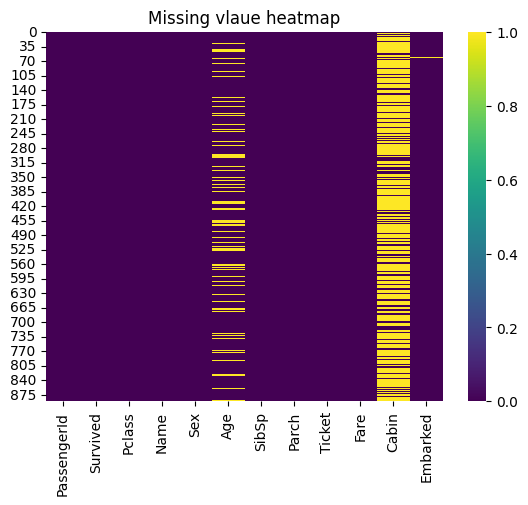

In [22]:
sns.heatmap(train.isnull(), cbar = "False", cmap = "viridis")
plt.title("Missing vlaue heatmap")
plt.show()

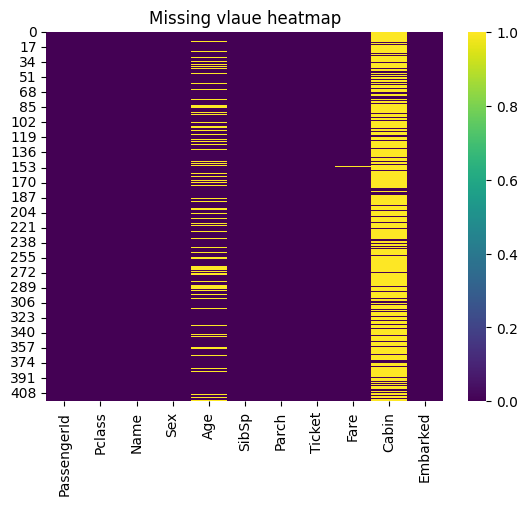

In [23]:
sns.heatmap(test.isnull(), cbar = "False", cmap = "viridis")
plt.title("Missing vlaue heatmap")
plt.show()

# Handle missing vlaues

In [24]:
train.shape

(891, 12)

In [25]:
train.dropna(thresh = len(train)*0.5, axis=1, inplace = True)


In [26]:
test.dropna(thresh = len(test)*0.5, axis=1, inplace = True)

In [27]:
train.shape

(891, 11)

# Fixed Numerical Columns

In [28]:
#Mean/Median  imputation for numerical columns

for i in train.columns:
    if(train[i].dtypes == 'float64'):
        print(i, train[i].dtypes, train[i].isna().sum())

Age float64 177
Fare float64 0


In [29]:

for i in test.columns:
    if(test[i].dtypes == 'float64'):
        print(i, test[i].dtypes, test[i].isna().sum())

Age float64 86
Fare float64 1


In [30]:
for i in train.columns:
    if(train[i].dtypes == 'float64' and train[i].isna().sum()!=0):
        print(i, train[i].dtypes, train[i].isna().sum())

Age float64 177


In [31]:
for i in train.columns:
    if(train[i].dtypes == 'float64' and train[i].isna().sum()!=0):
        train[i] = train[i].fillna(train[i].mean())
        print(i, train[i].dtypes, train[i].isna().sum())

Age float64 0


In [32]:
for i in test.columns:
    if(test[i].dtypes == 'float64' and test[i].isna().sum()!=0):
        test[i] = test[i].fillna(test[i].mean())
        print(i, test[i].dtypes, test[i].isna().sum())

Age float64 0
Fare float64 0


**Mode imputation for categorical column**

In [33]:
for i in train.columns:
    if(train[i].dtypes == 'object'):
        print(i, train[i].dtypes, train[i].isna().sum())

Name object 0
Sex object 0
Ticket object 0
Embarked object 2


In [34]:
for i in test.columns:
    if(test[i].dtypes == 'object'):
        print(i, test[i].dtypes, test[i].isna().sum())

Name object 0
Sex object 0
Ticket object 0
Embarked object 0


In [35]:
for i in train.columns:
    if(train[i].dtypes == 'object' and train[i].isna().sum()!=0):
        print(i, train[i].dtypes, train[i].isna().sum())

Embarked object 2


In [36]:
for i in train.columns:
    if(train[i].dtypes == 'object' and train[i].isna().sum()!=0):
        train[i] = train[i].fillna(train[i].mode())
        print(i, train[i].dtypes, train[i].isna().sum())

Embarked object 2


In [37]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [38]:
test.shape

(418, 10)

# Univariant Analysis

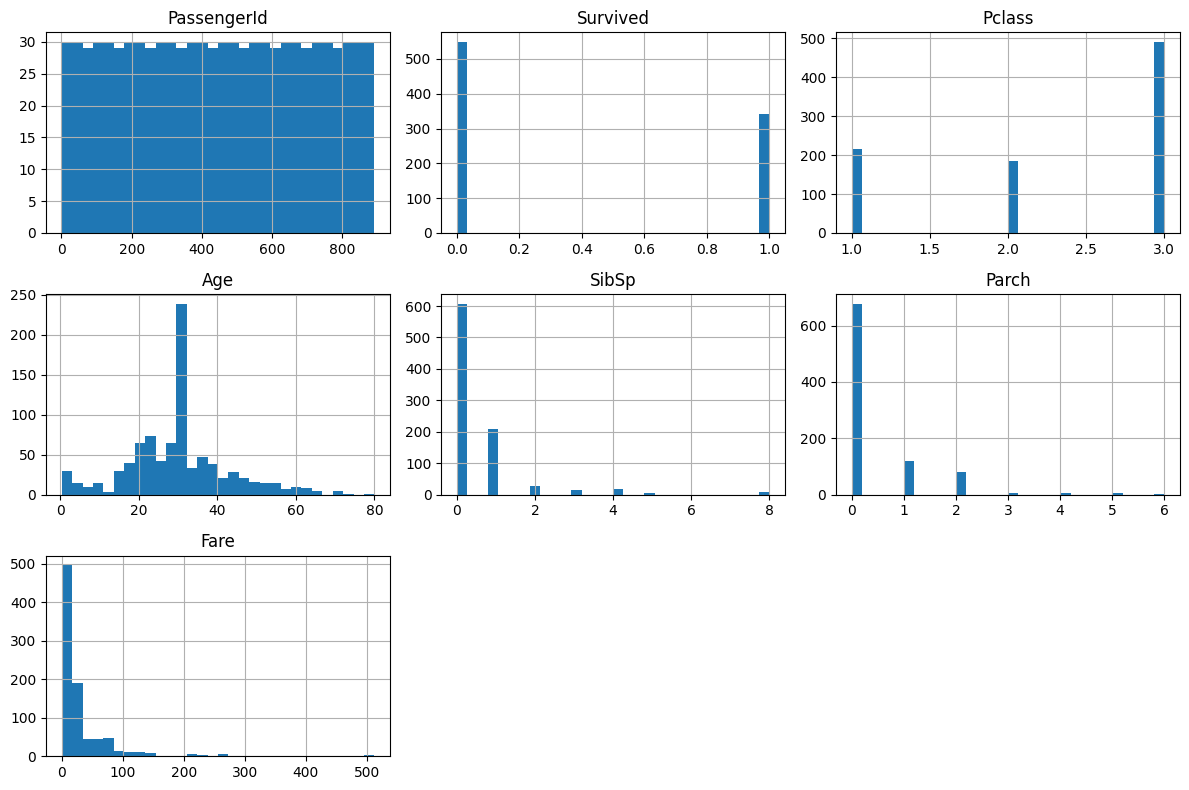

In [39]:
train.hist(figsize= (12,8), bins = 30)
plt.tight_layout()
plt.show()

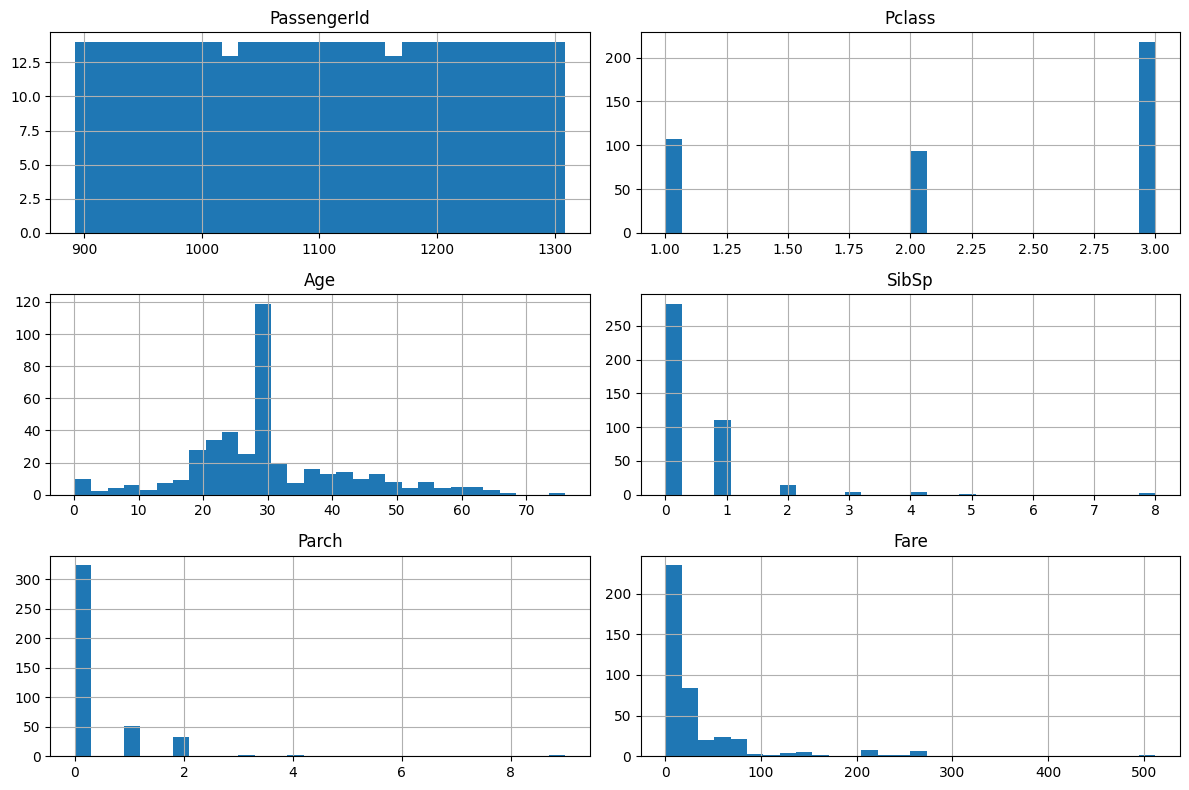

In [40]:
test.hist(figsize= (12,8), bins = 30)
plt.tight_layout()
plt.show()

**For Categorical Columns**

Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64


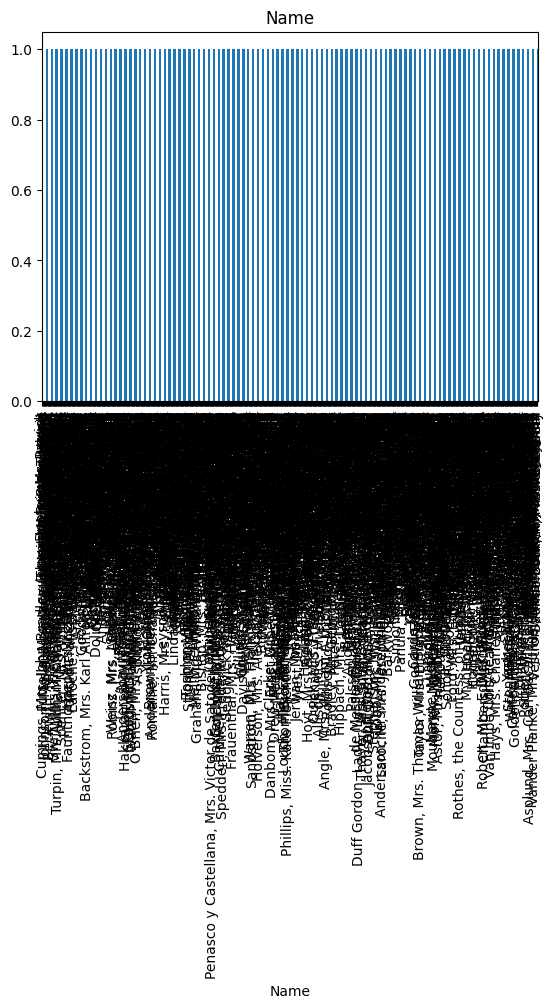

Sex
male      577
female    314
Name: count, dtype: int64


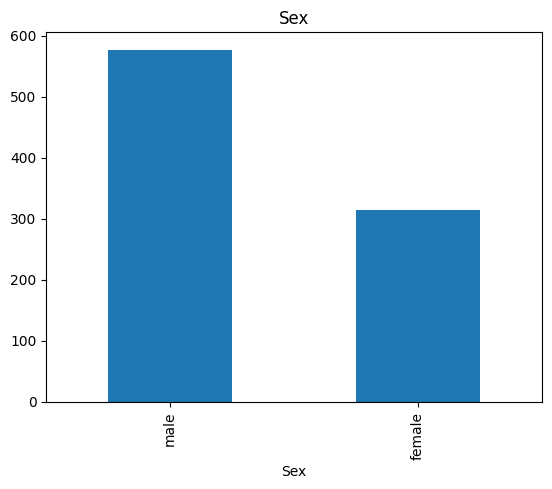

Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450              1
STON/O2. 3101282    1
Name: count, Length: 681, dtype: int64


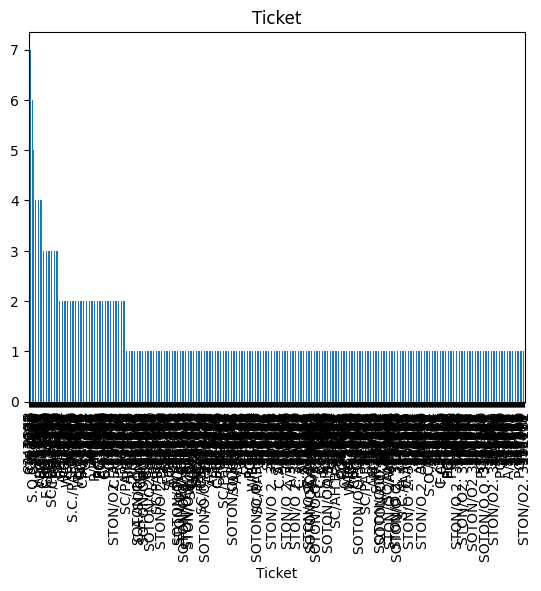

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


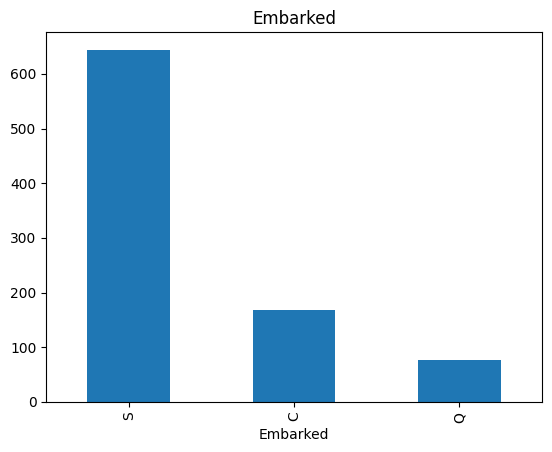

In [41]:
for col in train.columns:
    if(train[col].dtypes == 'object'):
        print(train[col].value_counts())
        train[col].value_counts().plot(kind = "bar", title = col)
        plt.show()

In [42]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [43]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [44]:
train.groupby('Age')['Survived'].mean()

Age
0.42     1.0
0.67     1.0
0.75     1.0
0.83     1.0
0.92     1.0
        ... 
70.00    0.0
70.50    0.0
71.00    0.0
74.00    0.0
80.00    1.0
Name: Survived, Length: 89, dtype: float64

In [45]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [46]:
def preprocess(df):
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.')
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    return df

In [47]:
train = preprocess(train)

In [48]:
test = preprocess(test)

# Feature Engineering

In [49]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  Title        891 non-null    object 
 12  FamilySize   891 non-null    int64  
 13  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 97.6+ KB


In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          418 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         418 non-null    float64
 9   Embarked     418 non-null    object 
 10  Title        418 non-null    object 
 11  FamilySize   418 non-null    int64  
 12  IsAlone      418 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 42.6+ KB


In [51]:
train['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

**Extract title**

In [52]:
test['Title'].value_counts()

Title
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [53]:
train['Title'].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [54]:
train.drop(['PassengerId','Name','Ticket'], axis = 1, inplace=True)

In [55]:
test.drop(['PassengerId','Name','Ticket'], axis = 1, inplace=True)

# Encode categorical Variables

In [56]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [57]:
for i in train:
    if(train[i].dtypes == 'object'):
        train[i]=le.fit_transform(train[i])
        print(i, train[i].dtypes)

Sex int64
Embarked int64
Title int64


In [58]:
for i in test:
    if(test[i].dtypes == 'object'):
        test[i]=le.fit_transform(test[i])
        print(i, test[i].dtypes)

Sex int64
Embarked int64
Title int64


In [59]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    int64  
 8   Title       891 non-null    int64  
 9   FamilySize  891 non-null    int64  
 10  IsAlone     891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


In [60]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      418 non-null    int64  
 1   Sex         418 non-null    int64  
 2   Age         418 non-null    float64
 3   SibSp       418 non-null    int64  
 4   Parch       418 non-null    int64  
 5   Fare        418 non-null    float64
 6   Embarked    418 non-null    int64  
 7   Title       418 non-null    int64  
 8   FamilySize  418 non-null    int64  
 9   IsAlone     418 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 32.8 KB


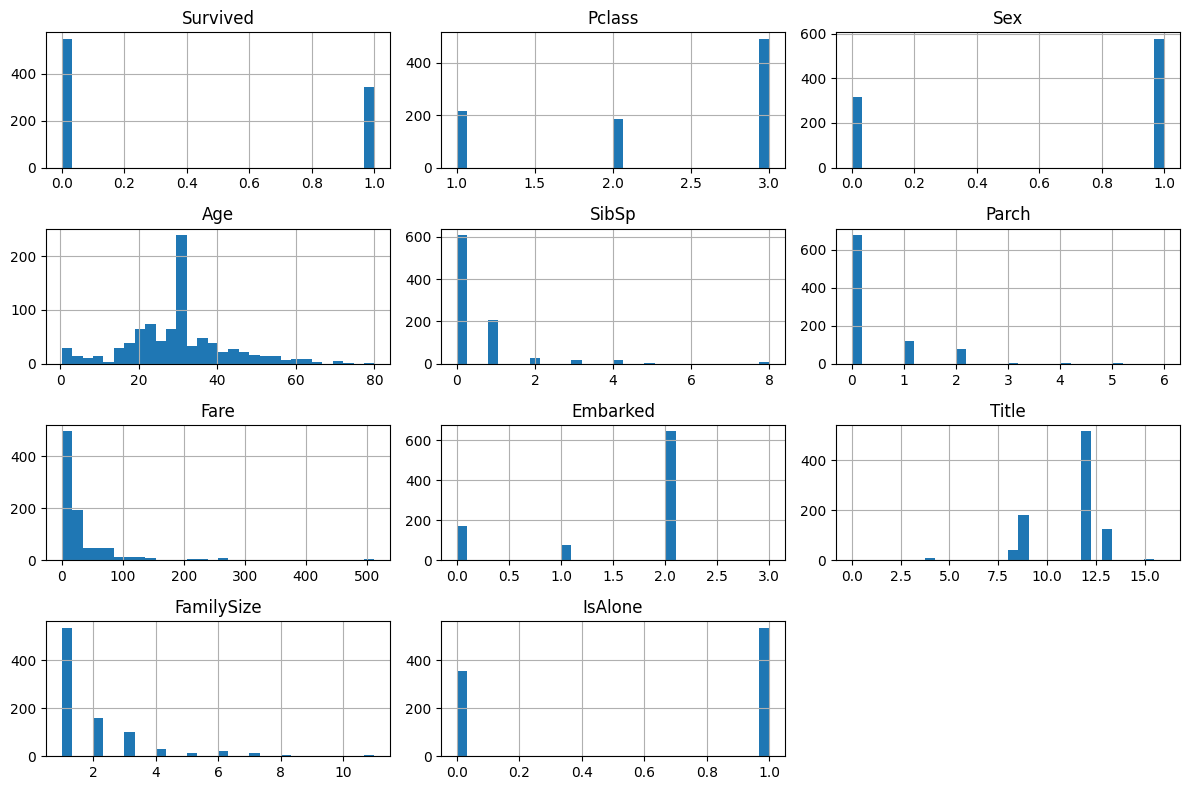

In [61]:
train.hist(figsize = (12,8), bins = 30)
plt.tight_layout()
plt.show()

# Train/Split

In [62]:
train['Survived'].value_counts().to_frame()

,count
Survived,
0,549
1,342


In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X = train.drop("Survived", axis = 1)
y= train["Survived"]

In [166]:
X.shape

(891, 10)

In [167]:
y.shape

(891,)

In [168]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=50)

In [169]:
print('Size of Train X', len(X_train))
print('Size of Train y',len(y_train))
print('Size of Test X',len(X_test))
print('Size of Test y',len(y_test))

Size of Train X 712
Size of Train y 712
Size of Test X 179
Size of Test y 179


**Classification Models**

In [170]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

In [171]:
LModel = LogisticRegression(solver='liblinear',random_state=10)

In [172]:
LModel.fit(X_train,y_train)
LogisticRegression(random_state=10, solver='liblinear')

LogisticRegression(random_state=10, solver='liblinear')

In [173]:

training_data_prediction_lr = LModel.predict(X_train)
print(training_data_prediction_lr)

[0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 1 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1
 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 1
 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0
 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1
 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0
 1 0 0 0 0 1 0 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 1 0 1 1 0 0 0 1 

In [174]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [175]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_lr))
print("Precission : ",precision_score(y_train,training_data_prediction_lr,average='weighted'))
print("Recall_score : ",recall_score(y_train,training_data_prediction_lr,average='weighted'))
print("F1_score : ",f1_score(y_train,training_data_prediction_lr,average='weighted'))

Accuracy :  0.8075842696629213
Precission :  0.8053122075927771
Recall_score :  0.8075842696629213
F1_score :  0.805009277589494


In [176]:
from sklearn.metrics import classification_report
report_lr_train = classification_report(y_train, training_data_prediction_lr,output_dict=True)
print(report_lr_train)

{'0': {'precision': 0.8259958071278826, 'recall': 0.8794642857142857, 'f1-score': 0.8518918918918919, 'support': 448.0}, '1': {'precision': 0.7702127659574468, 'recall': 0.6856060606060606, 'f1-score': 0.7254509018036072, 'support': 264.0}, 'accuracy': 0.8075842696629213, 'macro avg': {'precision': 0.7981042865426646, 'recall': 0.7825351731601731, 'f1-score': 0.7886713968477495, 'support': 712.0}, 'weighted avg': {'precision': 0.8053122075927771, 'recall': 0.8075842696629213, 'f1-score': 0.805009277589494, 'support': 712.0}}


In [177]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

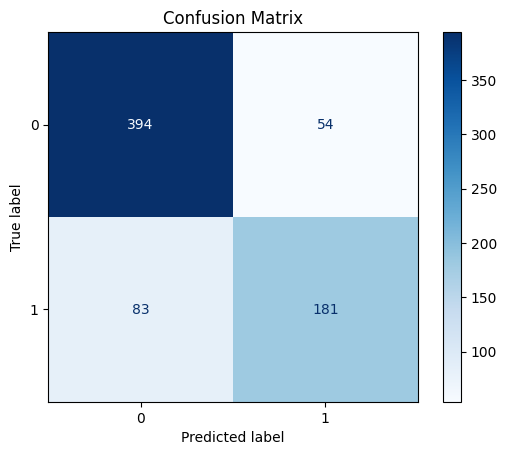

In [178]:
cm = confusion_matrix(y_train, training_data_prediction_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [179]:
testing_data_prediction_lr = LModel.predict(X_test)
# testing_data_prediction_lr= LModel.predict_proba(X_test)[:,1]
print(testing_data_prediction_lr)

[1 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 0 0 0 0 1 1 1 1
 0 1 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0
 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1
 1 1 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0
 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 1 0 0 1 1 0 0 0 0 0 1 0 1]


In [180]:
print("Accuracy :", accuracy_score(y_test, testing_data_prediction_lr))
print("Precision:", precision_score(y_test, testing_data_prediction_lr,average='weighted'))
print("Recall   :", recall_score(y_test, testing_data_prediction_lr,average='weighted'))
print("F1 Score :", f1_score(y_test, testing_data_prediction_lr,average='weighted'))

Accuracy : 0.7932960893854749
Precision: 0.7958149563853769
Recall   : 0.7932960893854749
F1 Score : 0.7901496450801375


In [181]:
from sklearn.metrics import classification_report
report_lr_test = classification_report(y_test, testing_data_prediction_lr,output_dict=True)
print(report_lr_test)

{'0': {'precision': 0.7807017543859649, 'recall': 0.8811881188118812, 'f1-score': 0.827906976744186, 'support': 101.0}, '1': {'precision': 0.8153846153846154, 'recall': 0.6794871794871795, 'f1-score': 0.7412587412587412, 'support': 78.0}, 'accuracy': 0.7932960893854749, 'macro avg': {'precision': 0.7980431848852901, 'recall': 0.7803376491495304, 'f1-score': 0.7845828590014636, 'support': 179.0}, 'weighted avg': {'precision': 0.7958149563853769, 'recall': 0.7932960893854749, 'f1-score': 0.7901496450801375, 'support': 179.0}}


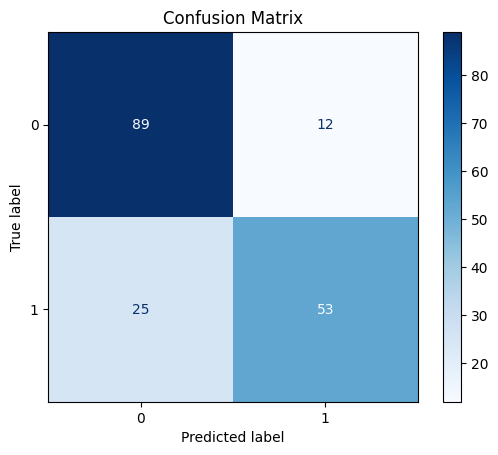

In [182]:
cm = confusion_matrix(y_test, testing_data_prediction_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [183]:
# DEcission Tree Classifier
from sklearn.tree import DecisionTreeClassifier

In [184]:
Dtree = DecisionTreeClassifier(random_state=30, max_depth = 4)


In [185]:
Dtree.fit(X_train, y_train)
DecisionTreeClassifier(random_state=30, max_depth = 4)

DecisionTreeClassifier(max_depth=4, random_state=30)

In [186]:
training_data_prediction_Dt =Dtree.predict(X_train)
print(training_data_prediction_Dt)

[0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1
 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1
 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0
 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 1 0 0 1 0 0 0 1 

In [187]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_Dt))
print("Precission : ",precision_score(y_train,training_data_prediction_Dt,average='weighted'))
print("Recall_score : ",recall_score(y_train,training_data_prediction_Dt,average='weighted'))
print("F1_score : ",f1_score(y_train,training_data_prediction_Dt,average='weighted'))

Accuracy :  0.8426966292134831
Precission :  0.8416892677256879
Recall_score :  0.8426966292134831
F1_score :  0.8403344540125732


In [188]:

report_dt_train =classification_report(y_train, training_data_prediction_Dt,output_dict=True)
print(report_dt_train)

{'0': {'precision': 0.85, 'recall': 0.9107142857142857, 'f1-score': 0.8793103448275862, 'support': 448.0}, '1': {'precision': 0.8275862068965517, 'recall': 0.7272727272727273, 'f1-score': 0.7741935483870968, 'support': 264.0}, 'accuracy': 0.8426966292134831, 'macro avg': {'precision': 0.8387931034482758, 'recall': 0.8189935064935066, 'f1-score': 0.8267519466073414, 'support': 712.0}, 'weighted avg': {'precision': 0.8416892677256879, 'recall': 0.8426966292134831, 'f1-score': 0.8403344540125732, 'support': 712.0}}


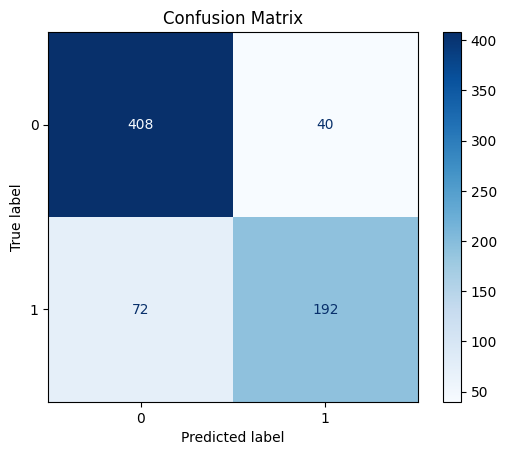

In [189]:
cm = confusion_matrix(y_train, training_data_prediction_Dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [190]:
testing_data_prediction_Dt = Dtree.predict(X_test)
# testing_data_prediction_Dt= Dtree.predict_proba(X_test)[:,1]
print(testing_data_prediction_Dt)

[1 0 0 0 1 0 0 0 1 1 1 1 0 1 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1 0 0 0 1 1 1 1
 0 1 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0
 1 0 1 0 1 0 1 0 0 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1]


In [191]:
print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_Dt))
print("Precission : ",precision_score(y_test,testing_data_prediction_Dt,average='weighted'))
print("Recall_score : ",recall_score(y_test,testing_data_prediction_Dt,average='weighted'))
print("F1_score : ",f1_score(y_test,testing_data_prediction_Dt,average='weighted'))

Accuracy :  0.776536312849162
Precission :  0.7777408234717771
Recall_score :  0.776536312849162
F1_score :  0.7734906629074645


In [192]:

report_dt_test = classification_report(y_test, testing_data_prediction_Dt,output_dict=True)
print(report_dt_test)

{'0': {'precision': 0.7699115044247787, 'recall': 0.8613861386138614, 'f1-score': 0.8130841121495327, 'support': 101.0}, '1': {'precision': 0.7878787878787878, 'recall': 0.6666666666666666, 'f1-score': 0.7222222222222222, 'support': 78.0}, 'accuracy': 0.776536312849162, 'macro avg': {'precision': 0.7788951461517832, 'recall': 0.764026402640264, 'f1-score': 0.7676531671858775, 'support': 179.0}, 'weighted avg': {'precision': 0.7777408234717771, 'recall': 0.776536312849162, 'f1-score': 0.7734906629074645, 'support': 179.0}}


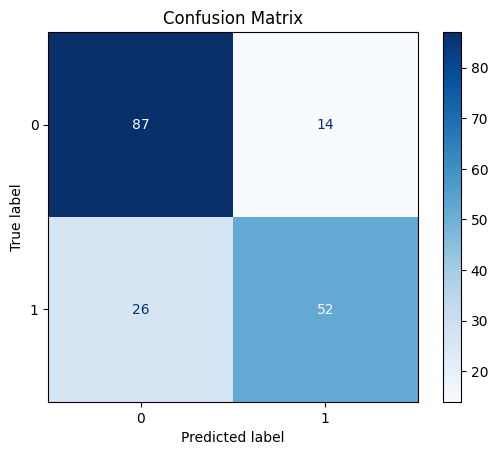

In [193]:
cm = confusion_matrix(y_test, testing_data_prediction_Dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [194]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression"],
    
    "Accuracy": [
        report_dt_train["accuracy"],
        report_lr_train["accuracy"]
    ],
    
    "F1 Score (Class 1)": [
        report_dt_train["1"]["f1-score"],
        report_lr_train["1"]["f1-score"]
    ],
    
    "Precision (Class 1)": [
        report_dt_train["1"]["precision"],
        report_lr_train["1"]["precision"]
    ],
    
    "Recall (Class 1)": [
        report_dt_train["1"]["recall"],
        report_lr_train["1"]["recall"]
    ],
     "Accuracy": [
        report_dt_test["accuracy"],
        report_lr_test["accuracy"]
    ],
    
    "F1 Score (Class 1)": [
        report_dt_test["1"]["f1-score"],
        report_lr_test["1"]["f1-score"]
    ],
    
    "Precision (Class 1)": [
        report_dt_test["1"]["precision"],
        report_lr_test["1"]["precision"]
    ],
    
    "Recall (Class 1)": [
        report_dt_test["1"]["recall"],
        report_lr_test["1"]["recall"]
    ]
})

In [195]:
comparison

,Model,Accuracy,F1 Score (Class 1),Precision (Class 1),Recall (Class 1)
0,Decision Tree,0.776536,0.722222,0.787879,0.666667
1,Logistic Regression,0.793296,0.741259,0.815385,0.679487


In [196]:
# Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

In [241]:
rf_model =RandomForestClassifier(    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=10)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=10)

In [242]:
training_data_prediction_rf =rf_model.predict(X_train)
print(training_data_prediction_rf)

[0 0 0 1 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 1 0 1 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1
 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1
 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0 1 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 1 0
 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 1 0 0 1 0 0 0 1 

In [243]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_rf))
print("Precission : ",precision_score(y_train,training_data_prediction_rf,average='weighted'))
print("Recall_score : ",recall_score(y_train,training_data_prediction_rf,average='weighted'))
print("F1_score : ",f1_score(y_train,training_data_prediction_rf,average='weighted'))

Accuracy :  0.8553370786516854
Precission :  0.8552827971348543
Recall_score :  0.8553370786516854
F1_score :  0.8527548892578916


In [244]:
testing_data_prediction_rf = rf_model.predict(X_test)
# testing_data_prediction_rf= rf_model.predict_proba(X_test)[:,1]
print(testing_data_prediction_rf)

[1 0 0 0 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 1
 0 1 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 0 1 0 0 0 0 0 0
 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1]


In [245]:
print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_rf))
print("Precission : ",precision_score(y_test,testing_data_prediction_rf,average='weighted'))
print("Recall_score : ",recall_score(y_test,testing_data_prediction_rf,average='weighted'))
print("F1_score : ",f1_score(y_test,testing_data_prediction_rf,average='weighted'))

Accuracy :  0.7988826815642458
Precission :  0.8009321473997403
Recall_score :  0.7988826815642458
F1_score :  0.796141596616718


**Important features of Random forest Classifier**

In [246]:
rf_model.feature_importances_

array([0.12931037, 0.36551304, 0.07466054, 0.03192884, 0.01460422,
       0.13791639, 0.01931927, 0.15957216, 0.05465603, 0.01251915])

In [247]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

In [248]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Sex,0.365513
7,Title,0.159572
5,Fare,0.137916
0,Pclass,0.129310
2,Age,0.074661
8,FamilySize,0.054656
3,SibSp,0.031929
6,Embarked,0.019319
4,Parch,0.014604
9,IsAlone,0.012519


In [205]:
# #SVM
from sklearn.svm import SVC

In [206]:
 from sklearn.preprocessing import StandardScaler

In [207]:

 scaler = StandardScaler()
 X_train_scaled = scaler.fit_transform(X_train)

In [208]:
 X_valid_scaled = scaler.transform(X_test)

In [209]:
SVM = SVC(kernel='rbf', C=1.0)

In [225]:
SVM.fit(X_train_scaled, y_train)
SVC(kernel='rbf', C=1.0,probability=True,random_state=42)

SVC(probability=True, random_state=42)

In [226]:
training_data_prediction_svm =SVM.predict(X_train_scaled)
print(training_data_prediction_svm)

[0 0 0 1 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 0 0 0 0 1 1 0
 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1
 0 0 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1
 1 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 0 1
 0 1 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 1 0 0 0
 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1
 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 0 1 1 0
 1 0 0 0 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 1 1 1 1 0 0 1 0 0 0 1 

In [227]:
print("Accuracy : ",accuracy_score(y_train,training_data_prediction_svm))
print("Precission : ",precision_score(y_train,training_data_prediction_svm,average='weighted'))
print("Recall_score : ",recall_score(y_train,training_data_prediction_svm,average='weighted'))
print("F1_score : ",f1_score(y_train,training_data_prediction_svm,average='weighted'))

Accuracy :  0.8426966292134831
Precission :  0.8413557038228326
Recall_score :  0.8426966292134831
F1_score :  0.8411618894966117


In [228]:
 testing_data_prediction_svm = SVM.predict(X_valid_scaled)
# # testing_data_prediction_svm= SVM.predict_proba(X_valid_scaled)[:,1]
 print(testing_data_prediction_svm)

[1 0 0 1 0 0 0 0 1 1 1 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 1
 0 1 0 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 0 0 1
 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0
 1 0 1 0 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 0 1]


In [229]:
 print("Accuracy : ",accuracy_score(y_test,testing_data_prediction_svm))
 print("Precission : ",precision_score(y_test,testing_data_prediction_svm,average='weighted'))
 print("Recall_score : ",recall_score(y_test,testing_data_prediction_svm,average='weighted'))
 print("F1_score : ",f1_score(y_test,testing_data_prediction_svm,average='weighted'))

Accuracy :  0.8268156424581006
Precission :  0.8279417934506592
Recall_score :  0.8268156424581006
F1_score :  0.8252075857481651


In [277]:

# Dictionary of already trained models
models = {
    "Logistic Regression": LModel,
    "Decision Tree":Dtree,
    "Random Forest": rf_model,
    "SVM": SVM
}

# Store results
results = []

for name, model in models.items():

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy and F1
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    # AUC-ROC
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    auc = roc_auc_score(y_test, y_score)

    # Save results
    results.append([name, acc, f1, auc])

# Comparison table
comparison_table = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "F1 Score", "AUC_ROC"]
)

print(comparison_table)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [250]:
rf_model = RandomForestClassifier(   
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=10)
rf_model.fit(X, y)

RandomForestClassifier(max_depth=5, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=10)

# Grid search cv

In [267]:
from sklearn.model_selection import GridSearchCV

In [268]:
# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, None]
}

In [269]:
# Random Forest model
rf_model = RandomForestClassifier(random_state=10)

In [271]:
# Grid Search CV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train grid search
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=10), n_jobs=-1,
             param_grid={'max_depth': [4, None], 'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [273]:
# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best CV score
print("Best CV Accuracy:", grid_search.best_score_)

# Best model
best_rf = grid_search.best_estimator_

Best Parameters: {'max_depth': 4, 'n_estimators': 100}
Best CV Accuracy: 0.8327686398108934


In [275]:

y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7988826815642458


In [278]:
test_pred =np.clip(grid_search.predict(test), 0, None)

In [279]:
original_test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")

In [280]:
original_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [281]:
submission2 = pd.DataFrame({
    'PassengerId': original_test['PassengerId'],
    'Survived': test_pred
})

In [282]:
submission2.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [283]:
submission2.shape

(418, 2)

In [284]:
submission2.to_csv('/kaggle/working/gender_submission2.csv', index=False)